In [3]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

51.150173611111114


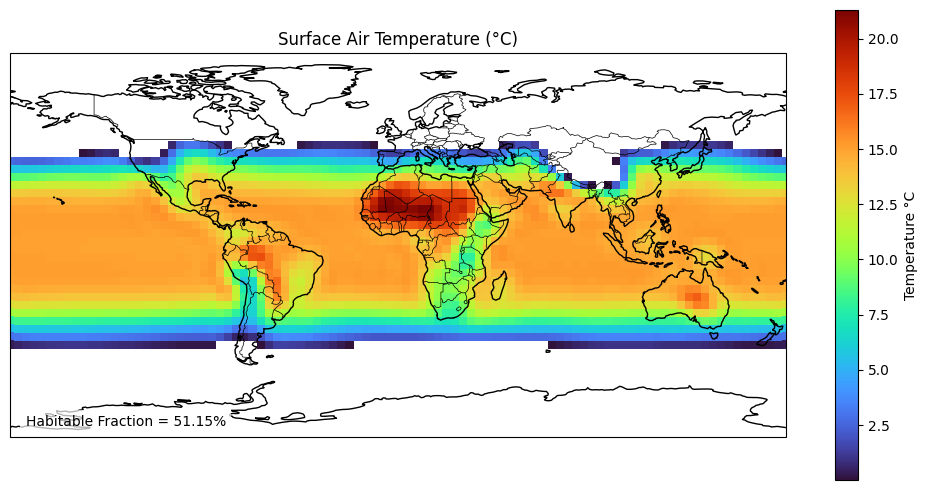

In [11]:
path = "run_0034/output.nc"
ds = xr.open_dataset(path)
da_tsurf = ds["tsurf"].mean(dim="time")
hab_tsurf = (da_tsurf >= 0) & (da_tsurf <= 48) 
hab_fraction_tsurf = hab_tsurf.mean().item() * 100
print(hab_fraction_tsurf)

fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

da_tsurf.where(hab_tsurf).plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={"label": "Temperature °C"},
    cmap = "turbo"
)

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.set_title("Surface Air Temperature (°C)")

ax.text(0.02, 0.02, f"Habitable Fraction = {hab_fraction_tsurf:.2f}%",
    transform=ax.transAxes,
    ha="left", va="bottom",
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
)
plt.tight_layout()

In [ ]:
# Habitability fraction for surface air temperature

hab_frac_tsurf = []

for idx in range(1, 21):

    path = f"rotation_trials/output_rot_{idx}.nc"
    ds = xr.open_dataset(path)


    da_mean = ds["tsurf"].mean(dim="time")

    hab_tsurf = (da_mean >= 0) & (da_mean <= 48)
    hab_fraction_tsurf = hab_tsurf.mean().item() * 100
    print(hab_fraction_tsurf)
    hab_frac_tsurf.append(hab_fraction_tsurf)

print(hab_frac_tsurf)

# Create the plot
fig = plt.figure(figsize=(10, 5))
plt.plot(rot_rate, hab_frac_tsurf, marker='o', linestyle='-', color='r')

# Add labels and title
plt.xlabel('Rotation rate \ $\Omega$ Earth')
plt.ylabel('% Habitability')
plt.title('Habitability (surface temperature) of Earth-like planets rotating at different rates')
plt.tight_layout()
#plt.savefig("rotation_trials/rot_tsurf.png")
plt.show()

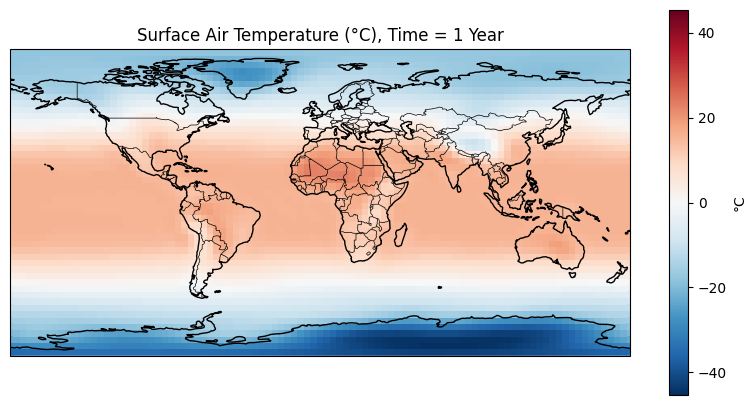

In [33]:
da = ds["tsurf"].mean(dim="time")

fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

da.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={"label": "°C"}
)

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.set_title("Surface Air Temperature (°C), Time = 1 Year")

plt.show()

In [34]:
t = ds["tsurf"]
print(t.attrs)

{'units': 'degC', 'long_name': 'Surface air temperature'}


In [35]:
masked_da = da.where((da >= -25) & (da <= 25))
valid = masked_da.notnull()
hab_fraction = valid.mean().item() * 100
print(hab_fraction)

91.57986111111111


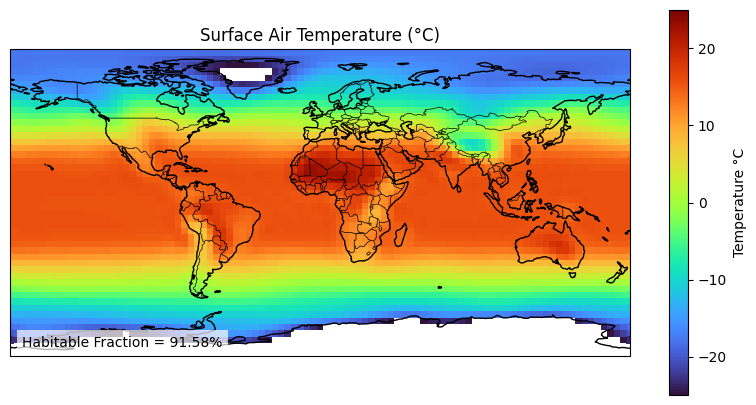

In [ ]:
fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

masked_da.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={"label": "Temperature °C"},
    cmap = "turbo"
)

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.set_title("Surface Air Temperature (°C)")

ax.text(0.02, 0.02, f"Habitable Fraction = {hab_fraction:.2f}%",
    transform=ax.transAxes,
    ha="left", va="bottom",
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
)
plt.tight_layout()
#plt.savefig("habitability_tsurf_1year.png")

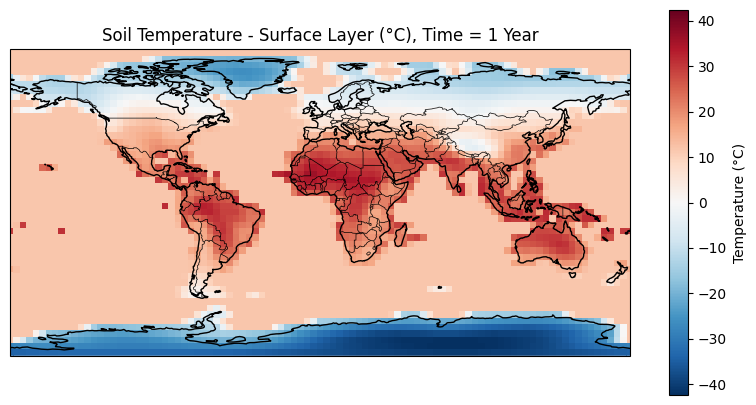

84.07118055555556


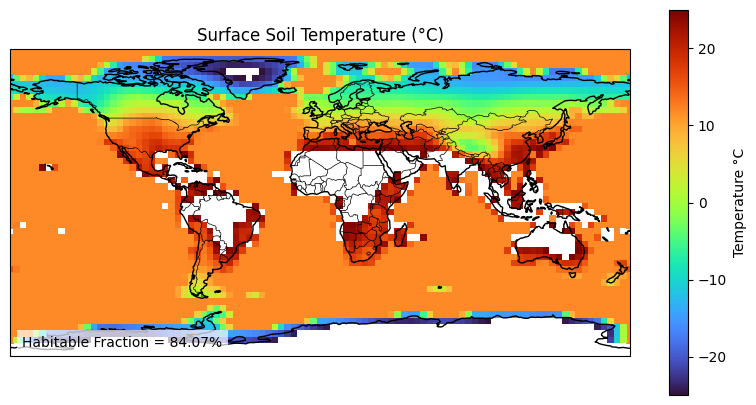

In [ ]:
# Habitability fraction for surface soil temperature

da = ds["st"].isel(soil_layer=0).mean(dim="time")

fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

da.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={"label": "Temperature (°C)"}
)

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.set_title("Soil Temperature - Surface Layer (°C), Time = 1 Year")

plt.show()

st = ds["st"]
masked_da_st = da.where((da >= -25) & (da <= 25)) 
valid_st = masked_da_st.notnull()
hab_fraction_st = valid_st.mean().item() * 100
print(hab_fraction_st)

fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

masked_da_st.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={"label": "Temperature °C"},
    cmap = "turbo"
)

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.set_title("Surface Soil Temperature (°C)")

ax.text(0.02, 0.02, f"Habitable Fraction = {hab_fraction_st:.2f}%",
    transform=ax.transAxes,
    ha="left", va="bottom",
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
)
plt.tight_layout()
#plt.savefig("habitability_st_1year.png")

In [26]:


# Average soil moisture content over the simulation run
mean_sm_top = ds["sm"].isel(soil_layer=0).mean(dim="time")
mean_sm_bottom = ds["sm"].isel(soil_layer=1).mean(dim="time")

Habitable fraction  = 11.72%


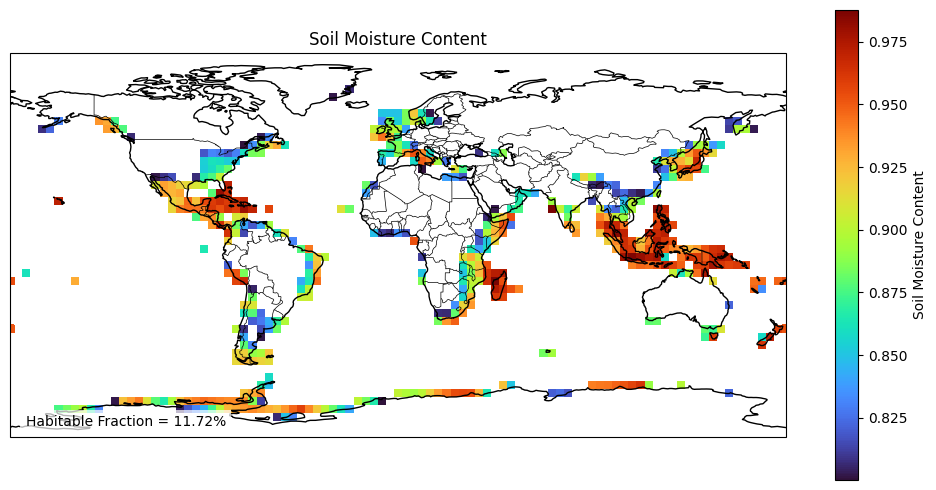

In [ ]:
# Habitability fraction for soil moisture content


top_ok = mean_sm_top >= 0.8

# habitability fraction: both layers
hab_fraction_sm = top_ok.mean().item() * 100
print(f"Habitable fraction  = {hab_fraction_sm:.2f}%")

sm_plot = mean_sm_top.where(top_ok)

fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

sm_plot.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={"label": "Soil Moisture Content"},
    cmap = "turbo"
)

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.set_title("Soil Moisture Content")

ax.text(0.02, 0.02, f"Habitable Fraction = {hab_fraction_sm:.2f}%",
    transform=ax.transAxes,
    ha="left", va="bottom",
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
)
plt.tight_layout()
#plt.savefig("habitability_sm0.8_1year.png")
plt.show()